# 리포트 8-2 — 마이크로도플러: 세 엔진과 거리

> **8 권은 다섯 편이다** — [08_1 시나리오](08_1_scene.ipynb) · [08_2 세 엔진과 거리](08_2_engines.ipynb) · [08_3 무늬를 정하는 것](08_3_pattern.ipynb) · [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) · [08_5 바이스태틱](08_5_bistatic.ipynb)

> **같은 장면을 세 가지로 계산하면 무엇이 갈리나.** 대조군이 없으면 우리 맵이 틀렸는지 알 방법이 없다.

장면은 [08_1](08_1_scene.ipynb) 이 세웠다. 이 편은 **계산 엔진**만 다룬다.

⭐ 숫자는 전부 계산 결과 JSON(원장)에서 주입된다 — 원장이 다시 계산되면 `python src/make_report08_microdoppler.py` 한 번으로 본문 숫자가 따라 바뀐다.


## 세 엔진이 각각 무엇을 하나

| 엔진 | 무엇을 쏘나 | 무엇을 세나 | 무엇이 빠지나 |
|---|---|---|---|
| **Sionna PathSolver** | TX 에서 광선을 뿌린다 | 표적을 맞고 돌아온 **경로**의 진폭·지연으로 h = Σ a_p·e^(−j2πf_cτ_p) | 경로가 열 개 남짓이라 재료가 성기다. 프롭 정반사 경로는 **0 개**(아래) |
| **Ours (SBR+PO, 기본)** | 표적에 **앵커한** λ/12 격자로 평면파 조명 | 광선이 **처음 맞은 지점만** 면적분 — |Γ|·(n̂·û)·ΔA·위상 | 가려진 면이 자동으로 빠진다 (가림이 공짜) |
| **Ours w/o occlusion (대조)** | 광선을 안 쓴다 | 점구름의 **모든 면**을 더한다 (법선이 등진 면만 제외) | ⚠**아무것도 안 빠진다** — 남의 뒤에 숨은 면도 셈에 든다 |

⭐ 셋째 열은 **물리적으로 불가능한 상태**다. 오직 «가림이 얼마나 바꾸나» 를 재는 대조군으로만 쓴다. ⚠«드론 일부만 그린 것» 이 아니다 — 동체도 프로펠러도 다 들어간다.

⚠ **둘째와 셋째는 가림 말고 이산화 방식도 다르다**(광선 격자 ↔ 점구름). 그래서 둘의 차이가 «가림만» 의 값은 아니다. 가림만 떼어낸 깨끗한 축은 `report15b` 의 F(동체 Γ=0 — 막되 산란 안 함) ↔ G(동체 면만 제거, 정점은 남겨 광선 격자 동일) 이고, 그 실측이 배 쪽에서 최대 −15.96 dB 다.


## 세 엔진을 같은 격자에, 거리 3 / 8 / 15 m

**시나리오** — 같은 기체·자세·주파수·PRF·로터별 회전수로 세 엔진을 돌리고 거기에 거리축을 얹었다. 4096 표본 @ PRF 19700 Hz = 26 블레이드 주기, 로터 산포 ±0.22 %(PX4 **SITL**(소프트웨어 시뮬) 중간값 — ⚠실기 계측이 아니다). 기하는 **진짜 모노스태틱**(TX=RX, 기선 0)이다.

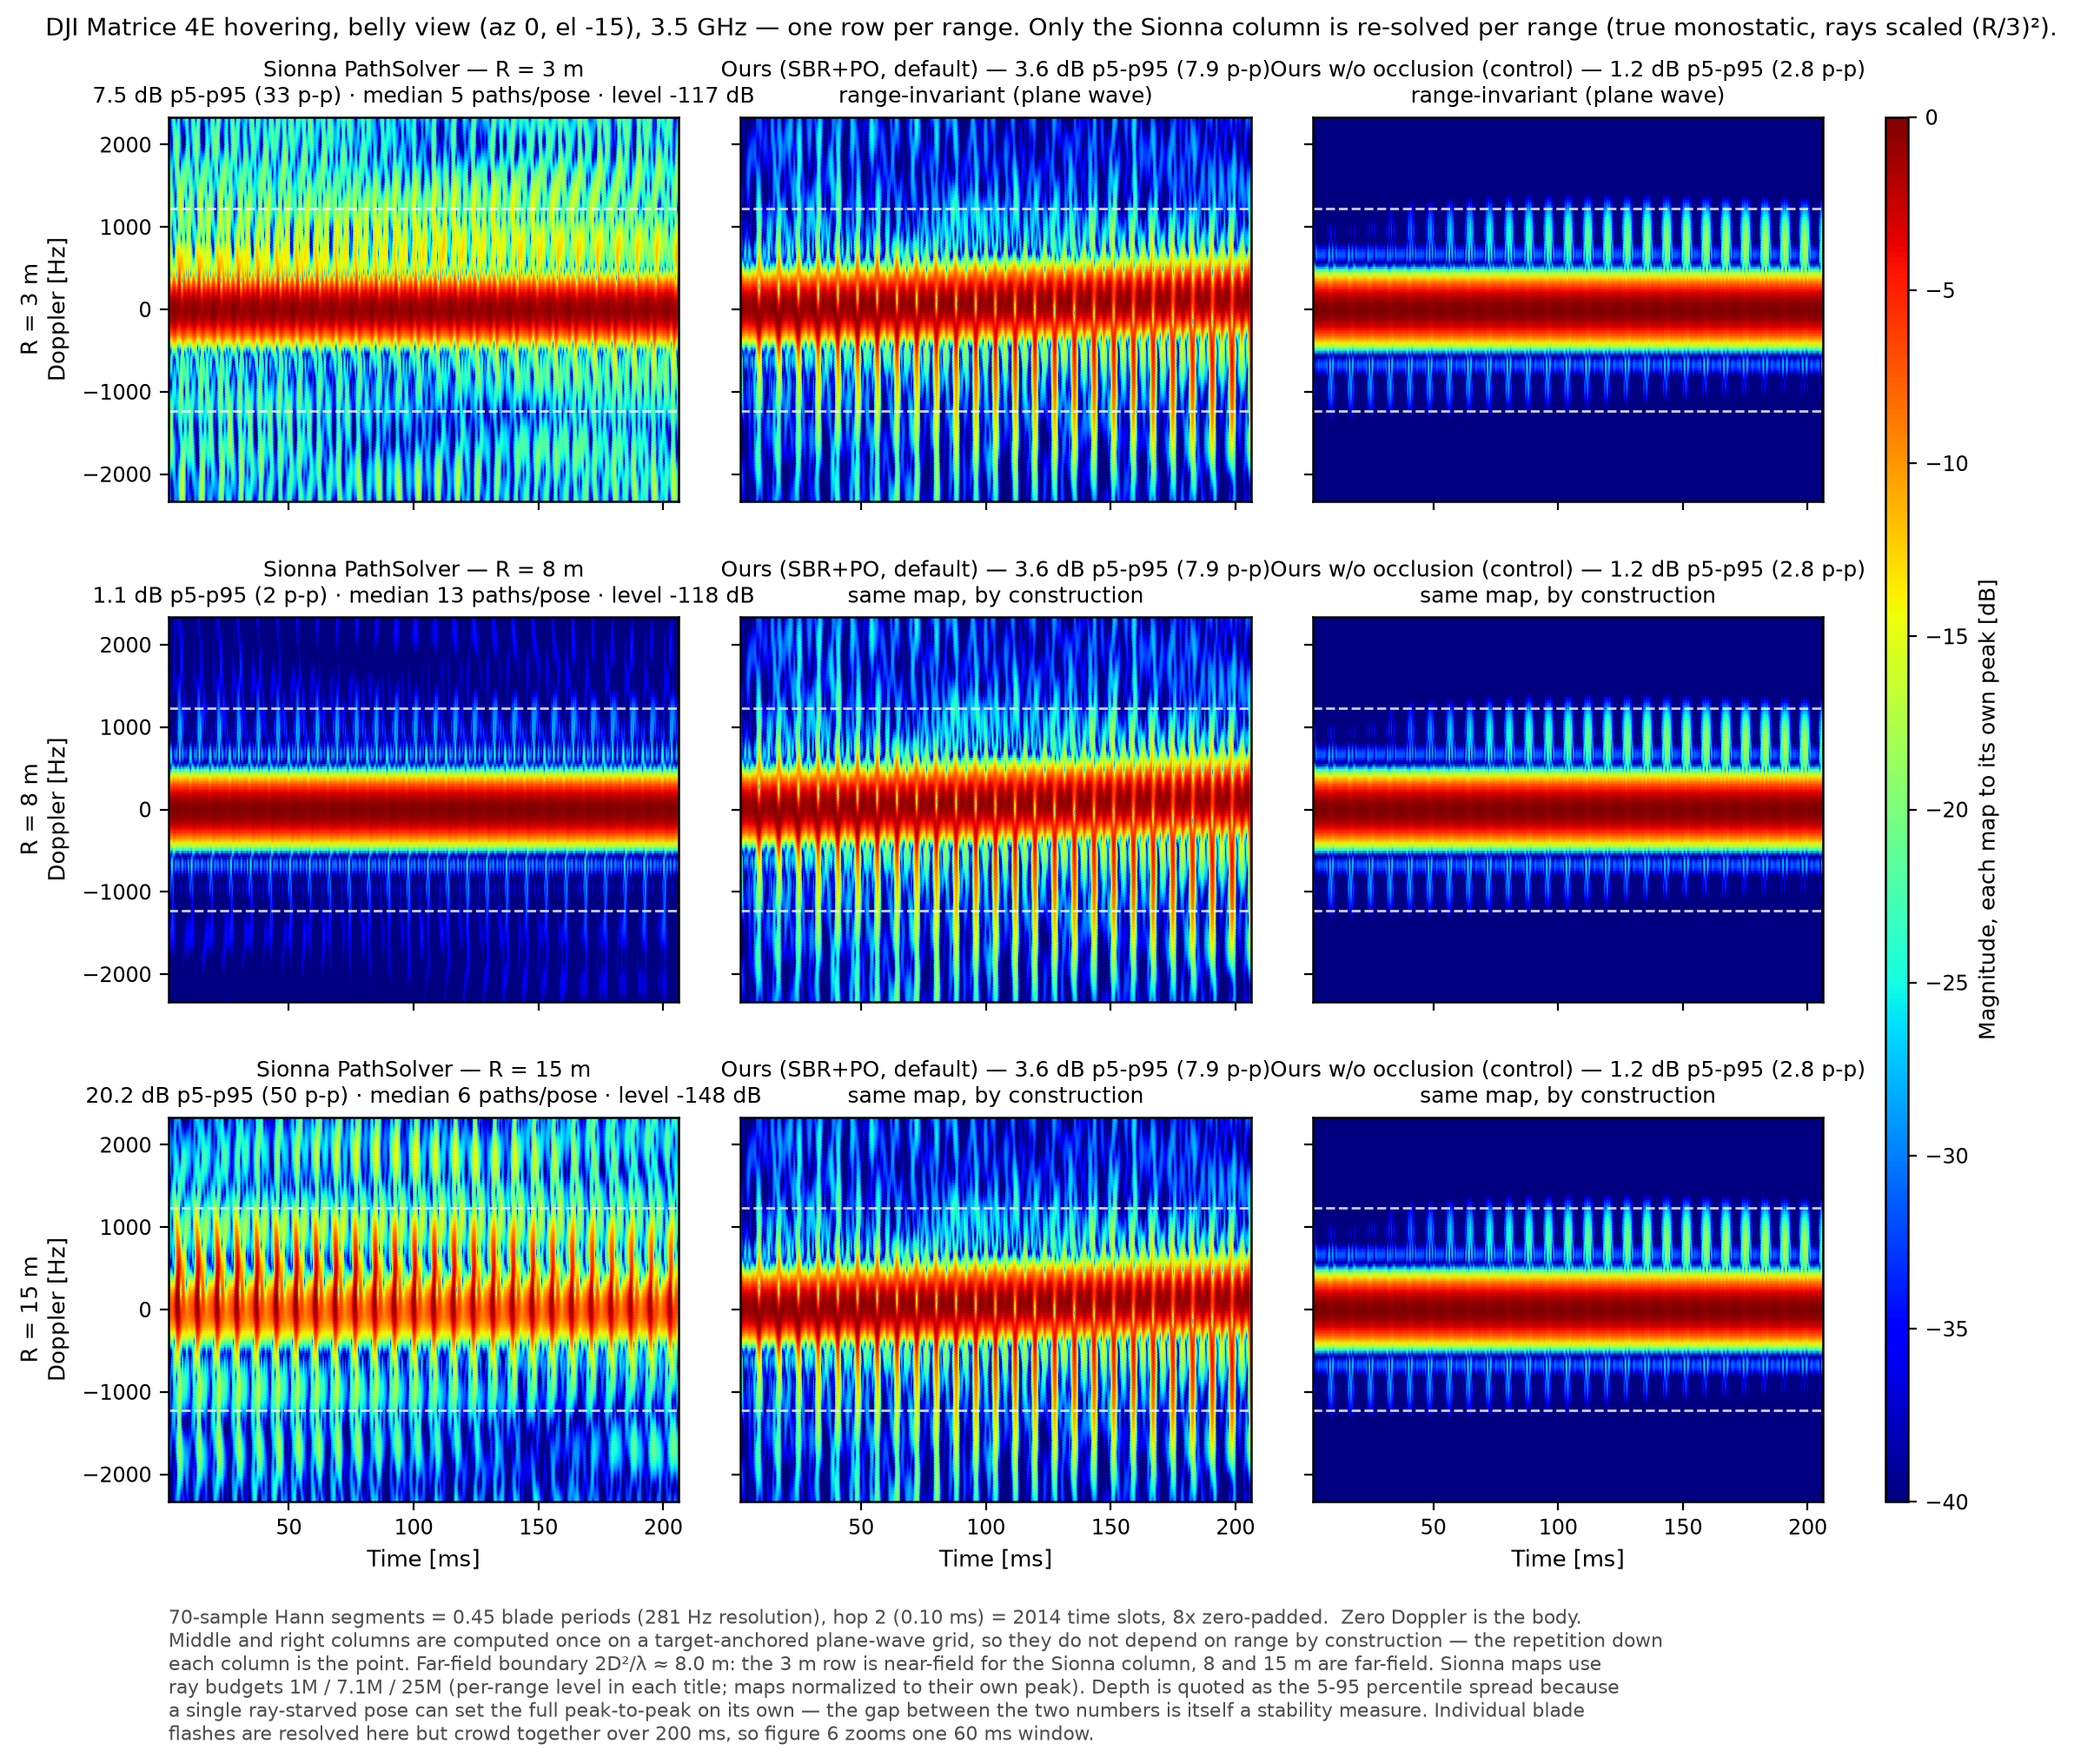

⭐ **왼쪽 열만 거리마다 다시 풀었다.** 가운데·오른쪽 열은 표적 앵커 평면파 조명이라 **거리라는 변수 자체가 없고**, 그래서 세 줄에서 같은 맵이 반복된다 — 그 반복이 이 그림의 절반이다. 8 m 는 원거리장 경계(8.3 m) 바로 곁이다.

**깊이는 두 자로 잰다** — p-p(max−min)는 자세 하나가 혼자 끌 수 있어서, 양 끝 5 %를 버린 **p5~p95** 를 함께 낸다. 둘의 **비**가 그 팔의 안정성이다. 아래 표는 `outputs/report07_depth_robust.json` 을 읽는다.

| 엔진 | p-p | p5~p95 | 비 | 무늬 |
|---|---|---|---|---|
| Sionna PathSolver | 7.7 dB | 4.0 dB | 1.9× | 무늬가 성기고 날개끝 근처에서 잦아든다 |
| Ours (SBR+PO, 기본) | 7.9 dB | 3.6 dB | 2.2× | ⚠능선이 대역을 채우고 날개끝 밖에도 남는다 |
| Ours w/o occlusion | 2.8 dB | 1.2 dB | 2.3× | 능선이 몇 가닥에 그친다 |

⚠ **이 표의 깊이를 물리량으로 인용하지 마라.** 같은 Sionna 팔을 거리만 바꿔 재면 p-p 가 32.6 / 2.5 / 50.1 dB 로 요동친다(3 / 8 / 15 m). 그 요동은 물리가 아니라 **광선 표본화**다 — 강건한 p5~p95 로 보면 7.5 / 1.1 / 20.2 dB 다. ⚠ 다만 **«자세 하나가 전폭을 혼자 정한다» 는 과장이었다** — 최솟값 자세를 빼고 다시 재도 3 m 는 27.1 dB, 15 m 는 45.1 dB 가 남는다. 이상치 **하나**가 아니라 **꼬리가 두꺼운 것**이다.

⭐ 셋 다 **(a) 0 도플러 동체 선 · (b) 통과율 간격 능선 · (c) 날개끝 근처 감쇠**를 낸다 — 구조가 일치한다. 날개끝 안 스펙트럼 코사인은 Sionna↔SBR+PO **0.727** · Sionna↔w/o occ **0.660** · 기본↔대조 **0.440** 다.

⚠ **코사인 세 자리를 그대로 인용하지 마라 — 격자에 딸려 움직인다.** 같은 두 팔을 다른 광선 격자로 다시 재니 기본↔대조가 0.44 에서 0.29 로 내려갔다. 즉 이 수는 «두 무늬가 얼마나 닮았나» 의 절대 척도가 아니라 **이 실행에서의 순서**(Sionna 는 우리 기본팔과 가장 닮았고, 우리 두 팔끼리가 가장 덜 닮았다)만 말한다. 절대값이 필요하면 격자 사다리를 먼저 태워야 한다.

| 거리 | 광선 수 | 자세당 경로(중앙값) | 경로 0 자세 | 평균 레벨 |
|---|---|---|---|---|
| 3 m | 1.0M | 5 | 0.0% | -117.4 dB |
| 8 m | 7.1M | 13 | 0.0% | -118.0 dB |
| 15 m | 25.0M | 6 | 0.0% | -148.3 dB |


## 블레이드 플래시를 세 엔진으로 나란히 (60 ms 확대)

**시나리오** — 위와 **같은 원장·같은 슬로타임 격자·같은 로터 회전수**에서 60 ms 만 잘라 확대했다. 세 패널의 차이는 **산란 엔진뿐**이다. 조각은 블레이드 한 주기의 0.45 배라 플래시가 시간평균으로 지워지지 않는다.

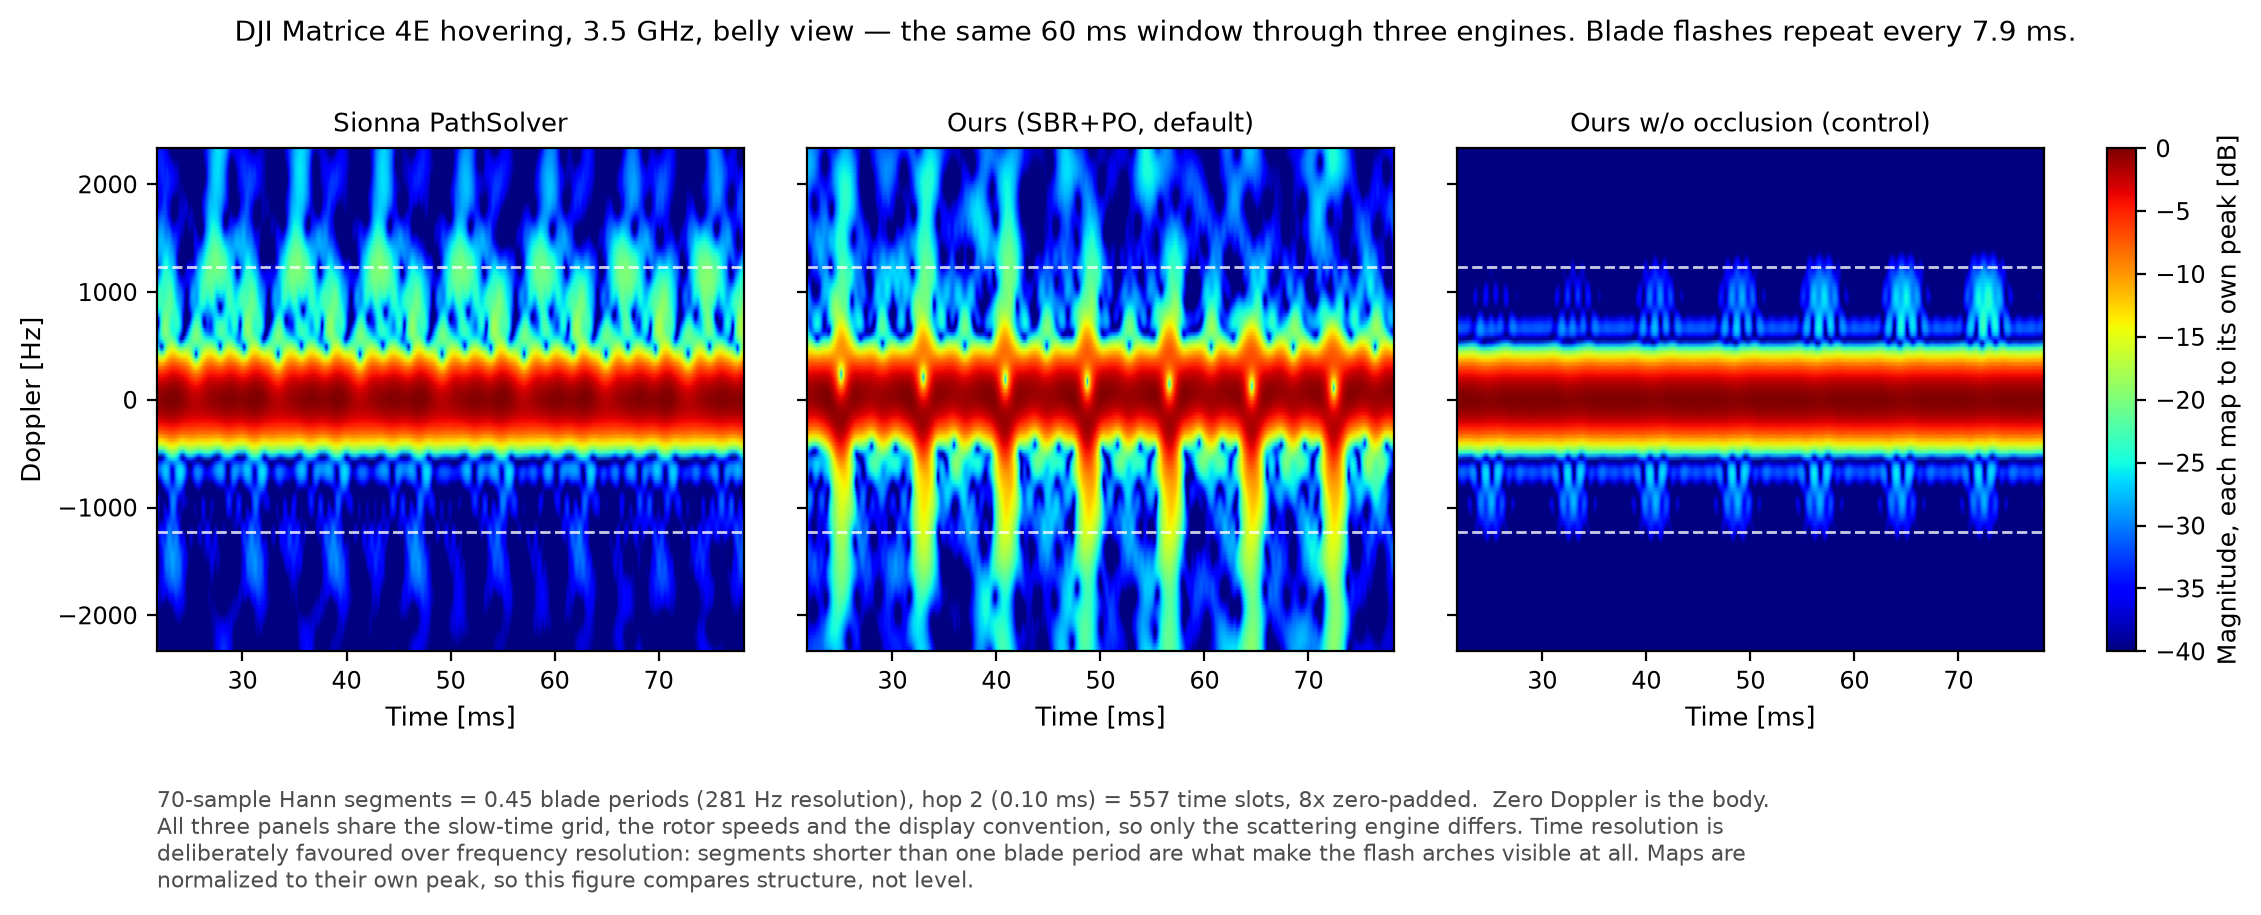

⭐ 세로 아치가 블레이드 플래시이고 **7.9 ms 마다** 반복한다(= f_flash 127 Hz). 세 엔진이 그 주기를 같이 낸다는 것이 이 그림의 첫 확인이다. 모양은 갈린다 — 가림을 켠 우리 기본팔은 아치가 굵고 도플러축으로 넓게 퍼지고, 가림을 끈 대조군은 좁고 또렷한 점처럼 떨어지며, Sionna 는 아치라기보다 얼룩에 가깝다.

⭐ **Sionna 가 왜 얼룩인가** — 프로펠러를 맞은 **정반사 경로가 0 개**다. 자세×위상 격자 1152 칸 전수에서 정반사가 잡힌 칸이 16 칸인데 그중 **프롭 정반사는 0 칸**이다(광선 2.56 억 발, 앙각 0~60°). 남은 것은 확산 산란뿐이라 아치가 뭉개진다.

⚠⚠ **이 «0» 은 아직 예산 사다리를 안 태웠다.** 2.56 억은 이 프로젝트가 쓰는 광선 사다리의 **맨 아랫칸**이고, 같은 사다리의 윗칸은 40.96 억(16 배)이다. 우리는 바로 이번 주에 «40 m 는 PathSolver 의 구조적 한계» 라고 적었다가 예산을 올리니 빈 자세가 77.3 % → 0 % 로 사라지는 것을 봤다 — 같은 함정이다. ⇒ 지금 정직하게 말할 수 있는 것은 «**이 예산에서는** 프롭 정반사가 안 잡힌다» 까지다. 윗칸 인구조사를 큐에 넣어 두었고, 결과가 나오면 이 절을 고친다. ⚠ 앙각도 60° 까지만이다 — 프롭 법선이 향하는 더 가파른 쪽은 이 격자 밖이다.

⭐ **시간 분해능을 주파수 분해능보다 앞세운다.** 조각을 한 주기보다 길게 잡으면 플래시는 그 안에서 평균돼 사라지고 가로 능선만 남는다. 그래서 조각을 **한 주기보다 짧게**(0.45 주기) 잡는다.

⚠ 예전 판은 여기에 «플래시 대비» 라는 지표의 표를 붙여 0.45 가 최대라고 적었다. **그 표는 내렸다** — 독립 재구현에서 재현되지 않았고(같은 지표를 다시 재니 0.60 이 더 컸다), 지표의 정의가 산문 한 줄뿐이라 사람마다 다르게 잰다. 원장 JSON 도 없다. 0.45 는 **그림이 실제로 또렷해서** 유지하는 값이지 측정으로 증명된 최적점이 아니다. 지금 인용해도 되는 것은 정의가 하나뿐인 양뿐이다 — 조각 70 표본 · Δt 3.55 ms · Δf 281 Hz.

⚠ 세 패널은 각자 최대로 정규화했다 — 이 그림은 **구조를 비교하지 레벨을 비교하지 않는다**.

⚠⚠ **레벨을 «Sionna 가 60 dB 아래» 라고 읽으면 안 된다.** 두 팔이 내는 양의 **단위가 다르다** — Sionna 는 1/R² 를 두 번 먹은 **수신 전력장**을 주고, 우리 커널은 표적의 **산란 진폭**[m²]을 준다. 3 m 에서 그 환산항만 −20log₁₀(4πR²) = **−41.1 dB** 다. 실측 격차 −59.9 dB 에서 환산을 빼면 남는 것은 **약 −19 dB** 이고, 그것이 «프롭 정반사 경로가 0 개» 로 설명해야 할 몫이다. 단위가 다른 두 수를 빼서 얻은 «60 dB» 를 물리량으로 인용하지 마라.


## 두 엔진이 날개끝 아래에서 겹치고 위에서 갈린다

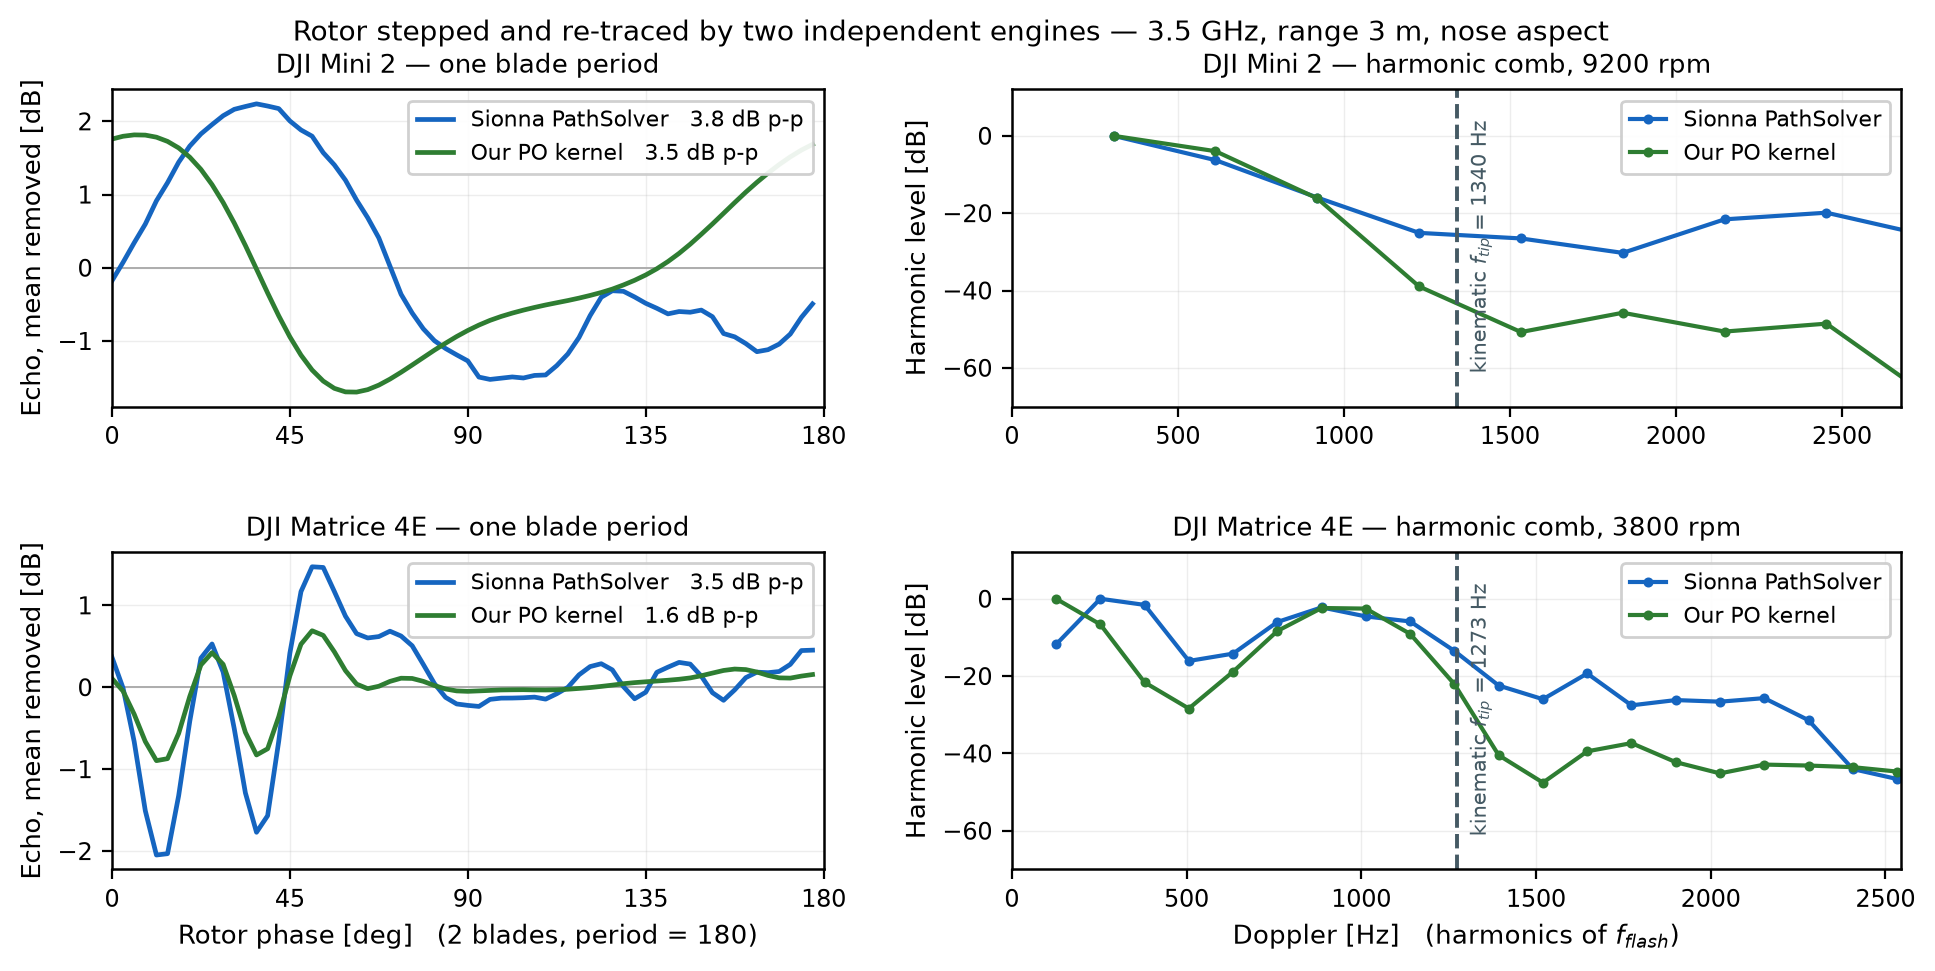

1 차원 스펙트럼으로 보면 두 엔진이 **날개끝 주파수 아래에서 겹치고 위에서 갈린다**. Sionna 꼬리가 순수 PO 대비 **14.7 dB**(matrice4e) · **27.4 dB**(mini2) 높다.

⚠ **이 그림만 자세가 다르다** — 08_1 의 배 쪽(el −15)이 아니라 nose(el +15)다. 원장이 2026-08-04 판이라 그렇다. 무늬 세부를 위 맵들과 직접 견주면 안 된다.


## 이 편이 서 있는 자리

세 엔진이 **같은 주기**를 내고 **모양이 갈린다**. 그 갈림의 원인은 가림과 경로 수다.

| 다음 | 무엇을 답하나 |
|---|---|
| [08_3 무늬를 정하는 것](08_3_pattern.ipynb) | 회전수·가림·산포가 무늬를 어떻게 바꾸나 |
| [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) | 이 계산을 얼마나 멀리·얼마나 자주 할 수 있나 |
| `reports/09_microdoppler-limits.ipynb` | 자세·보정·광선 예산의 단일축 분해 |
